In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
b=pd.read_csv('Titanic-Dataset.csv')

In [3]:
b.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
b.shape

(891, 12)

In [5]:
b.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [6]:
b.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
b.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
b.duplicated().sum()

np.int64(0)

In [9]:
b['Age']=b['Age'].fillna(b['Age'].mean())

In [10]:
b.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
b=b.drop(columns='Cabin')

In [12]:
b.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')

In [13]:
b['Embarked'].mode()

0    S
Name: Embarked, dtype: str

In [14]:
b['Embarked']=b['Embarked'].fillna(b['Embarked'].mode()[0])

In [15]:
b.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [16]:
survival_count=b['Survived'].value_counts()
survival_count

Survived
0    549
1    342
Name: count, dtype: int64

<BarContainer object of 2 artists>

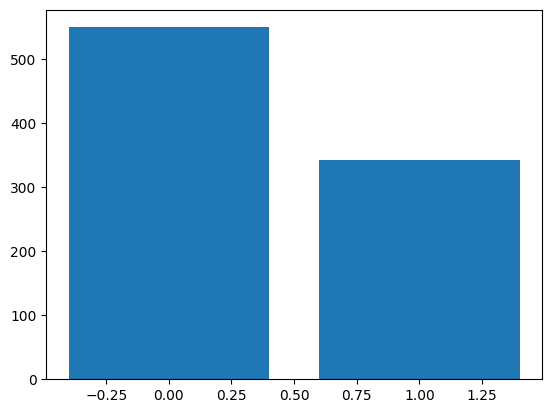

In [17]:
plt.Figure(figsize=(10,8))
plt.bar(survival_count.index,survival_count.values)

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


<BarContainer object of 3 artists>

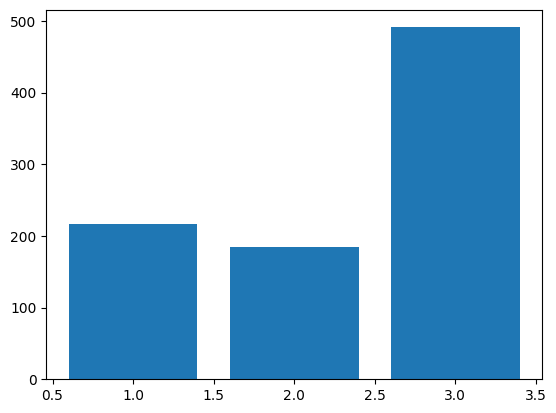

In [18]:
pclass_count=b['Pclass'].value_counts()
print(pclass_count)
plt.bar(pclass_count.index,pclass_count.values)
 

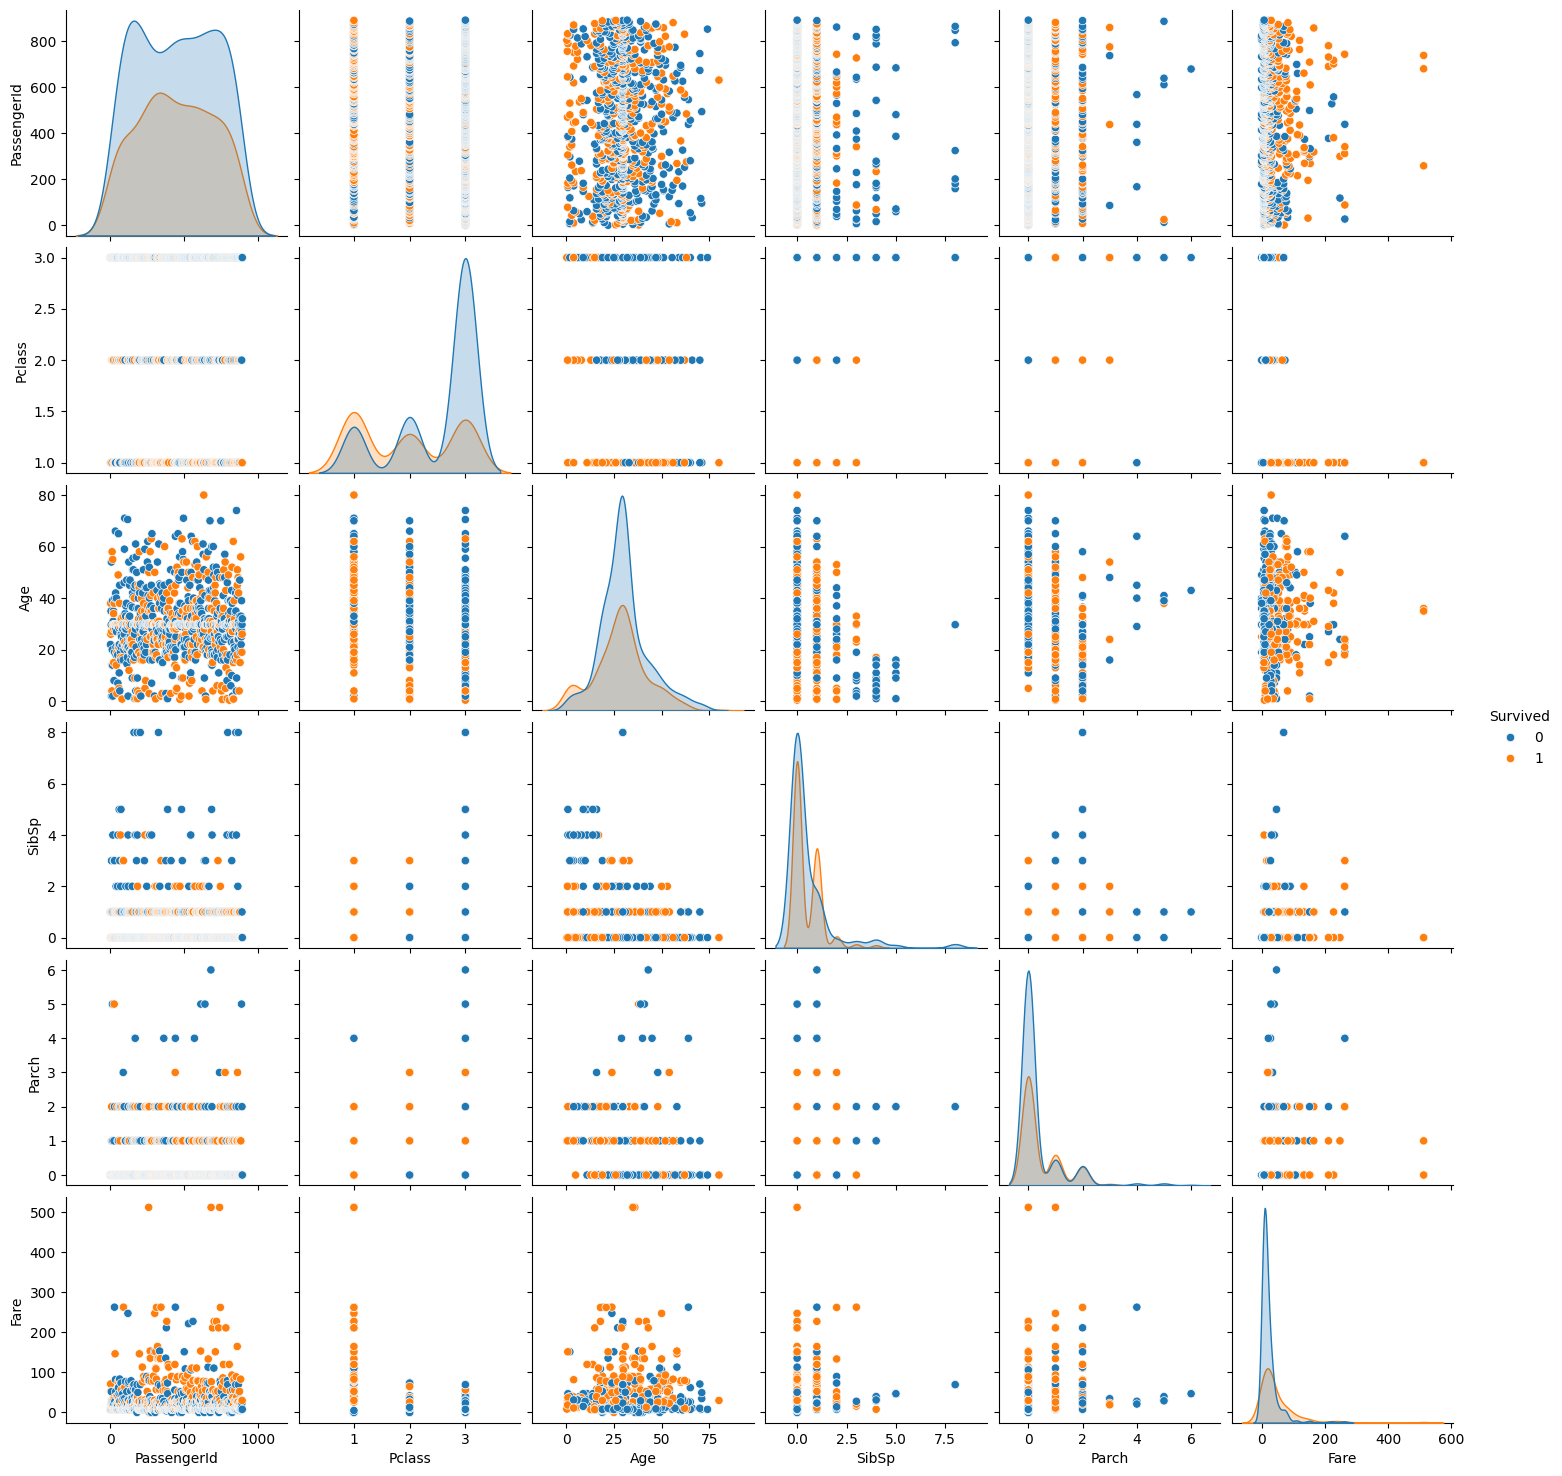

In [19]:
import seaborn as sns
sns.pairplot(data=b,hue='Survived')
plt.show()

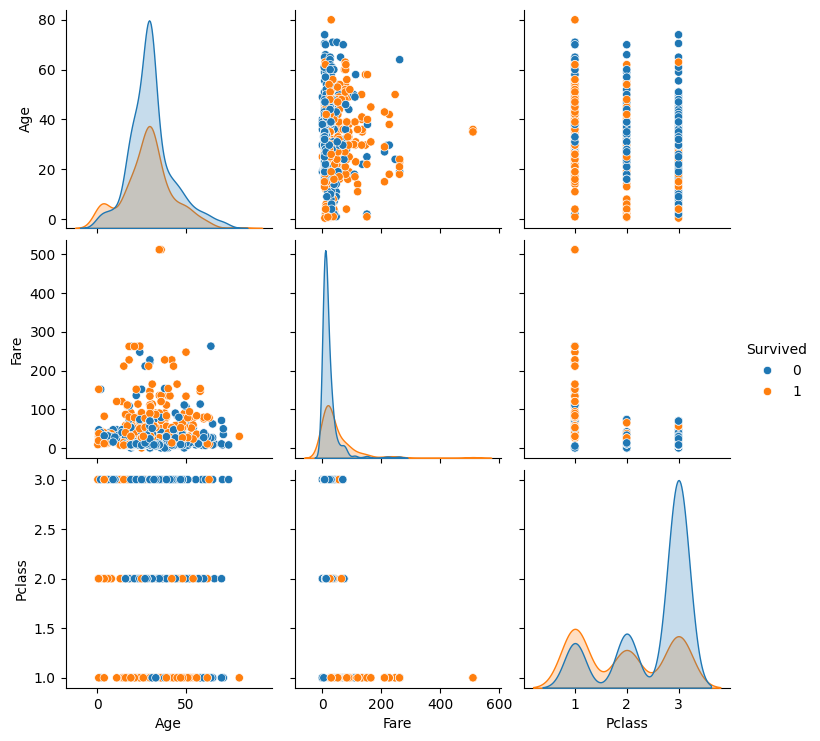

In [20]:
sns.pairplot(data=b,hue='Survived', vars=['Age','Fare','Pclass'])
plt.show()

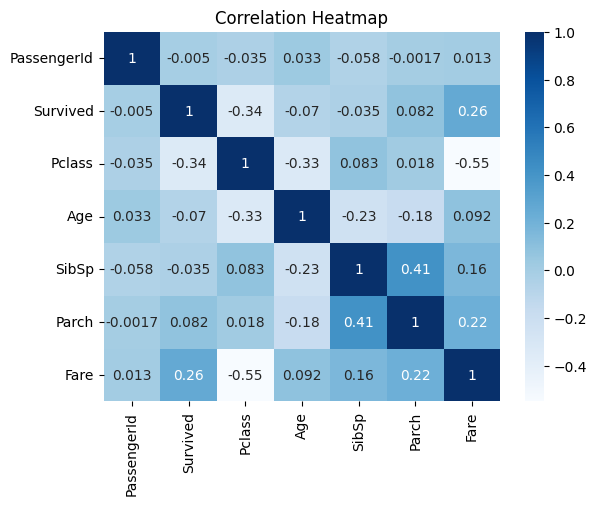

In [21]:
plt.Figure(figsize=(10,8))
sns.heatmap(b.corr(numeric_only=True), annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

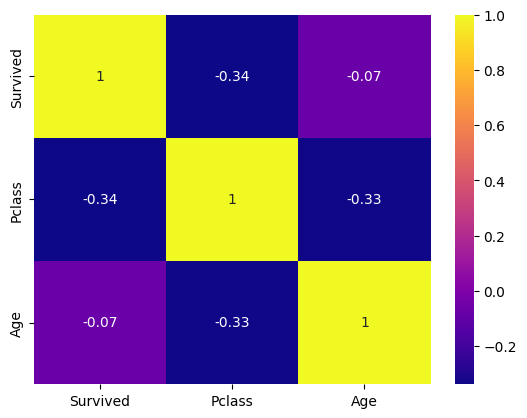

In [22]:
num_cols=b[['Survived','Pclass','Age']]
sns.heatmap(num_cols.corr(),annot=True,cmap='plasma')
plt.show()